# Generate Figures for a Single Run

Including:
1. Coefficients
2. Left and Right Modes

In [39]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.sparse.linalg import cg

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


'''
Fill in File Path
'''
file_path = '../allplots/sepsweep3/sep5/results.pkl'


########################################################

pickled_obj = {}
with open(file_path, 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]

# Normalize the modes
u_even = u_even / femsystem.integrate(lambda u,a,b: u**2,u_even)
u_odd = u_odd / femsystem.integrate(lambda u,a,b: u**2,u_odd)

u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
u_left_interior,u_right_interior = (u_even_interior+u_odd_interior)/jnp.sqrt(2), (u_even_interior-u_odd_interior)/jnp.sqrt(2)
theta_at_dofs = pickled_obj["theta_at_dofs"]
theta_at_interior = theta_at_dofs[femsystem.interior_dofs]
n,coeffs = pickled_obj["n"],pickled_obj["coeffs"]
E_J,E_C,e_0 = pickled_obj["E_J"],pickled_obj["E_C"],pickled_obj["e0"]
parameters = pickled_obj["parameters"]
totalTime = pickled_obj["totalTime"]

material = parameters["material"]
separation = parameters["separation"]
integrated_volume = pickled_obj["integrated_volume"]
sidelenX, sidelenY, sidelenZ = parameters["sidelenX"], parameters["sidelenY"], parameters["sidelenZ"]
volume = 2 * sidelenX * sidelenY * sidelenZ
print(f"Volume Integration Error: {(integrated_volume - volume) / volume * 100:.4g}% | Integrated Volume: {integrated_volume} | Volume: {volume}")

print(f"EJ: {E_J:.4g}, EC: {E_C:.4g}, EJ/EC: {E_J/E_C:.4g} | Time: {int(totalTime // 60)}m {int(totalTime % 60)}s | Degrees of Freedom: {femsystem.dofs}")
print(f"Parameters:")
print(parameters)
centerLeft,centerRight = ((sidelenX+separation)/2,0,0), (-(sidelenX+separation)/2,0,0)


Volume Integration Error: 0.2904% | Integrated Volume: 8023.22998046875 | Volume: 8000.0
EJ: 1.974, EC: 2.588, EJ/EC: 0.7629 | Time: 19m 43s | Degrees of Freedom: 56560
Parameters:
{'material': 0.0033784, 'separation': 5.0, 'sidelenX': 10.0, 'sidelenY': 20.0, 'sidelenZ': 20.0, 'padding': 20.0, 'gridlenX': 55.0, 'gridlenY': 60.0, 'gridlenZ': 60.0, 'lc_large': 15.0, 'lc_small': 1.0}


## 1. Coefficients

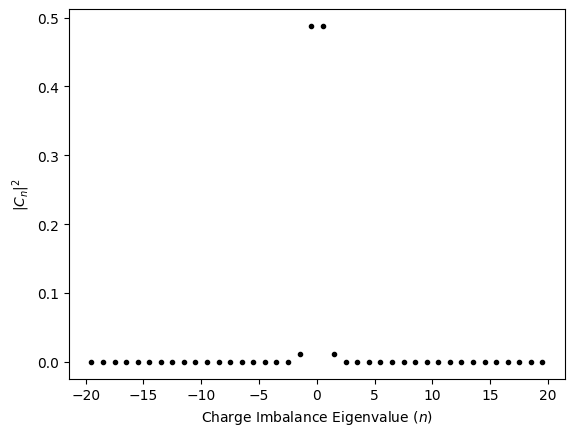

In [40]:
# Plot the coefficients of the eigenvectors, only the middle m
m = 20
x = (n-1)/2 - jnp.arange(n)

#normalize the coefficients
coeffs = (coeffs / jnp.sqrt(jnp.sum(coeffs**2)))**2

plt.plot(x[n//2-m:n//2+m],coeffs[n//2-m:n//2+m],".",color="black")
plt.xlabel(r"Charge Imbalance Eigenvalue ($n$)")
plt.ylabel(r"$|C_n|^2$")
plt.show()

## 2. Left and Right Modes

(<Figure size 800x800 with 2 Axes>,
 <Axes3D: title={'center': 'Right Mode'}>,
 <mpl_toolkits.mplot3d.art3d.Path3DCollection at 0x39f6dd7f0>)

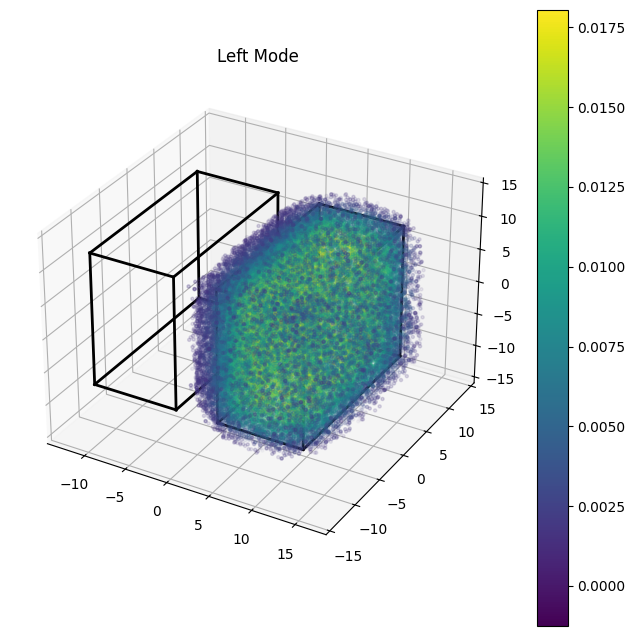

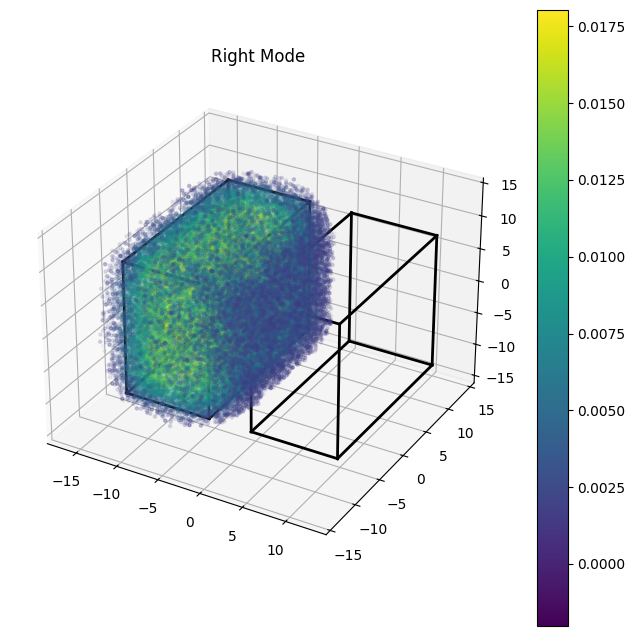

In [42]:
# Softer volumetric rendering (closer to the cloudy look in reference image 1)
threshold = 0.0015
max_points = 50000
prism_centers = [centerLeft,centerRight]
prism_side_lengths = [(sidelenX, sidelenY, sidelenZ),(sidelenX, sidelenY, sidelenZ)]
wire_color = "black"
wire_linewidth = 2.0
opacity_power = 1.5
alpha_lo = 0.2 #Opacity of lower values, lower is more transparent
alpha_hi = 0.01 #Opacity of higher values, lower is more transparent

# LEFT mode
femsystem.plot_interior_at_quad_3d_heatmap(u_left_interior, plot_title="Left Mode", max_points=max_points,value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers,
    prism_side_lengths=prism_side_lengths,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power
)

# RIGHT mode
femsystem.plot_interior_at_quad_3d_heatmap(u_right_interior, plot_title="Right Mode", max_points=max_points,value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers,
    prism_side_lengths=prism_side_lengths,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power
)

In [1]:
#  Qubit Frequency

 # Assume that half charge imbalance is perfectly centered around 0
# So odd n: -1 0 1 in middle, even n: -0.5 0.5 in middle
def eigensolver(n,E_J,E_C):
    # Construct charge imbalance Eigenvalues
    charge_imbalance_eigenvalues = (n-1)/2 - jnp.arange(n)

    # Construct Discrete Hamiltonian Matrix
    def Jz2(n):
        j = (n-1)/2
        diagonals = j - jnp.arange(n)
        return jnp.diag(diagonals**2)
    def off_diag(n,k):
        ones_super, ones_sub = jnp.ones(n - k, dtype=jnp.int32),jnp.ones(n - k, dtype=jnp.int32)
        super_diag_matrix,sub_diag_matrix= jnp.diag(ones_super, k=k),jnp.diag(ones_sub, k=-1*k)
        result = super_diag_matrix + sub_diag_matrix
        return result 
    def cos_phi(n):
        return off_diag(n,1) / 2
    hamiltonian = E_C * Jz2(n) - E_J * cos_phi(n) # No need for e_0 term, since we are only interested in eigenvectors

    # Find Eigenvalues and Eigenvectors
    eigenvalues,eigenvectors = jnp.linalg.eigh(hamiltonian)

    # Normalize eigenvectors
    eigenvectors = eigenvectors / jnp.sqrt(jnp.sum(jnp.abs(eigenvectors)**2, axis=0, keepdims=True))
    return hamiltonian, eigenvectors, eigenvalues, charge_imbalance_eigenvalues

hamiltonian, eigenvectors, eigenvalues, charge_imbalance_eigenvalues = eigensolver(n,E_J,E_C)
print(eigenvalues[1]-eigenvalues[0])

NameError: name 'n' is not defined